**Problem Statement-2**

Predict Term Deposit Subscription using Logistic Regression (Classification)

Syllabus mapping: Logistic Regression, Performance Metrics (Confusion Matrix, ROC, Precision/Recall/F1)
Goal: Build a binary classifier using Logistic Regression and report professional classification metrics.

Dataset (link):

UCI Bank Marketing Dataset: https://archive.ics.uci.edu/dataset/222/bank+marketing  

Problem Statement

A bank runs marketing campaigns to convince clients to subscribe to a term deposit (y = yes/no). You must build a model that predicts whether a client will subscribe based on demographic and campaign attributes. Since false positives and false negatives have different business costs, your evaluation must go beyond accuracy.

Expected Input

bank.csv (or bank-additional-full.csv as provided by UCI)
Program parameters:
--data bank.csv

--target y

--test_size 0.25

--threshold 0.5

Expected Output

Printed:
Confusion Matrix
Precision, Recall, F1-score
Sensitivity (Recall) and Specificity
ROC-AUC
Threshold analysis (minimum requirement):
Show metrics at two thresholds: 0.5 and one optimized threshold (chosen by you)
Files:
probabilities.csv with: RecordId, Probability(yes), PredictedLabel
Mandatory Tasks / Deliverables

Handle categorical data (encoding required)
Split train/test with proper random seed
Train Logistic Regression and report metrics
Explain:
why ROC curve is useful
what changes when the threshold changes (precision–recall trade-off)


1)Upload Dataset from Local System

In [2]:
from google.colab import files

uploaded = files.upload()


Saving bank.csv to bank (1).csv


2)Imports

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt


3)Loading dataset

In [5]:
import pandas as pd

data = pd.read_csv("bank (1).csv")
data.head()


,"age;""job"";""marital"";""education"";""default"";""balance"";""housing"";""loan"";""contact"";""day"";""month"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""y"""
0,"30;""unemployed"";""married"";""primary"";""no"";1787;..."
1,"33;""services"";""married"";""secondary"";""no"";4789;..."
2,"35;""management"";""single"";""tertiary"";""no"";1350;..."
3,"30;""management"";""married"";""tertiary"";""no"";1476..."
4,"59;""blue-collar"";""married"";""secondary"";""no"";0;..."


4)Dataset Overviews

In [7]:
data.head()


,"age;""job"";""marital"";""education"";""default"";""balance"";""housing"";""loan"";""contact"";""day"";""month"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""y"""
0,"30;""unemployed"";""married"";""primary"";""no"";1787;..."
1,"33;""services"";""married"";""secondary"";""no"";4789;..."
2,"35;""management"";""single"";""tertiary"";""no"";1350;..."
3,"30;""management"";""married"";""tertiary"";""no"";1476..."
4,"59;""blue-collar"";""married"";""secondary"";""no"";0;..."


In [8]:
data.columns


Index(['age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"'], dtype='object')

In [9]:
data = pd.read_csv("bank (1).csv", sep=';', quotechar='"')
data.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [10]:
print(data.shape)
print(data.columns)


(4521, 17)
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


5)Encode Target Variable

In [11]:
data['y'] = data['y'].map({'yes': 1, 'no': 0})


6)Separate Features and Target

In [12]:
X = data.drop('y', axis=1)
y = data['y']


7) Handle Categorical Variables

In [13]:
X = pd.get_dummies(X, drop_first=True)


8)Train–Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


9)Feature Scaling

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


10)Train Logistic Regression Model

In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

11)Predict Probabilities

In [17]:
y_prob = model.predict_proba(X_test)[:, 1]


**THRESHOLD ANALYSIS**

12)Predictions at Threshold = 0.5

In [18]:
threshold_05 = 0.5
y_pred_05 = (y_prob >= threshold_05).astype(int)


13)Metrics at Threshold = 0.5

In [19]:
cm_05 = confusion_matrix(y_test, y_pred_05)

precision_05 = precision_score(y_test, y_pred_05)
recall_05 = recall_score(y_test, y_pred_05)
f1_05 = f1_score(y_test, y_pred_05)
roc_auc = roc_auc_score(y_test, y_prob)

tn, fp, fn, tp = cm_05.ravel()
specificity_05 = tn / (tn + fp)

print("Confusion Matrix (Threshold = 0.5)\n", cm_05)
print("Precision:", precision_05)
print("Recall (Sensitivity):", recall_05)
print("Specificity:", specificity_05)
print("F1-score:", f1_05)
print("ROC-AUC:", roc_auc)


Confusion Matrix (Threshold = 0.5)
 [[975  26]
 [ 88  42]]
Precision: 0.6176470588235294
Recall (Sensitivity): 0.3230769230769231
Specificity: 0.974025974025974
F1-score: 0.42424242424242425
ROC-AUC: 0.8894951202643511


14)ROC Curve

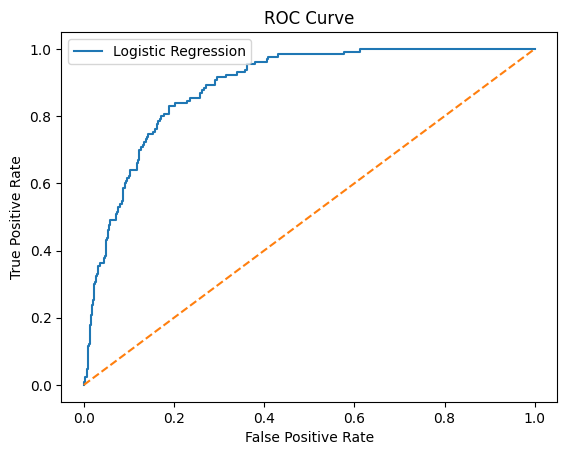

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


15)Find Optimized Threshold (Youden’s Index)

In [21]:
youden_index = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_index)]

optimal_threshold


np.float64(0.10242740428553268)

16)Metrics at Optimized Threshold

In [22]:
y_pred_opt = (y_prob >= optimal_threshold).astype(int)

cm_opt = confusion_matrix(y_test, y_pred_opt)
precision_opt = precision_score(y_test, y_pred_opt)
recall_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)

tn, fp, fn, tp = cm_opt.ravel()
specificity_opt = tn / (tn + fp)

print("Optimized Threshold:", optimal_threshold)
print("Confusion Matrix:\n", cm_opt)
print("Precision:", precision_opt)
print("Recall (Sensitivity):", recall_opt)
print("Specificity:", specificity_opt)
print("F1-score:", f1_opt)


Optimized Threshold: 0.10242740428553268
Confusion Matrix:
 [[811 190]
 [ 22 108]]
Precision: 0.3624161073825503
Recall (Sensitivity): 0.8307692307692308
Specificity: 0.8101898101898102
F1-score: 0.5046728971962616


17)Create probabilities.csv

In [23]:
output = pd.DataFrame({
    "RecordId": np.arange(1, len(y_prob) + 1),
    "Probability(yes)": y_prob,
    "PredictedLabel": np.where(y_pred_opt == 1, "yes", "no")
})

output.to_csv("probabilities.csv", index=False)
output.head()


,RecordId,Probability(yes),PredictedLabel
0,1,0.046608,no
1,2,0.226910,yes
2,3,0.131958,yes
3,4,0.154566,yes
4,5,0.022726,no


18)Download Output File

In [24]:
files.download("probabilities.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Why ROC Curve is Useful

The ROC curve evaluates model performance across all classification thresholds by plotting the True Positive Rate against the False Positive Rate. It helps in selecting an optimal threshold and comparing models independent of class distribution.

What Changes When Threshold Changes

Lowering the threshold increases recall but reduces precision, while increasing the threshold improves precision at the cost of recall. This trade-off allows the model to be aligned with business objectives.

**Conclusion**

Logistic Regression provides probability-based predictions that allow flexible threshold tuning, making it highly suitable for cost-sensitive banking classification problems